In [1]:
import pandas as pd
import numpy as np
import time
import h5py
import sys
import os
import matplotlib.pyplot as plt

from pyprodrisk import ProdriskSession

In [2]:
prodrisk = ProdriskSession(license_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk license", # absolute path to license file
                           solver_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268775wpdm_prapi_cvar_win\prapi_cvar_win\6.0.1_2026-06-12_020b04dce\Prodrisk_API_6.0.1_2026-06-12_020b04dce\pyprodrisk", # absolute path to pyprodrisk binaries
                           silent=False,        # write console output
                           sim_id=None)         # use default session id (a timestamp)

# --- configure settings for the session ---


# simulation period
prodrisk.set_optimization_period(
    pd.Timestamp("2030-01-04"),
    n_weeks=156
)

# time resolution
prodrisk.price_periods = pd.Series(
    index = [prodrisk.start_time + pd.Timedelta(hours=h) for h in 24*np.arange(7)],  # daily resolution
    data=1+np.arange(7)                                                              # 7 periods per week
)

# required file paths
local_dir = os.getcwd()
prodrisk.temp_dir = local_dir                                        # absolute path to make temporary files (here we're using location of this script)
prodrisk.log_file_path = local_dir                                   # absolute path where logfile is created
prodrisk.mpi_path = r"C:\Program Files\Microsoft MPI\bin"            # absolute path to mpi executables
prodrisk.prodrisk_path = r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268777wpdm_prodrisk_cvar_win\prodrisk_cvar_win"     # absolute path to Prodrisk executables
prodrisk.keep_working_directory = False                              # remove temporary files after the simulation

prodrisk.windows_core_delay = 10        # skip unnecessary waiting time
prodrisk.windows_api_delay  = 10        # ditto
prodrisk.max_iterations = 5             # low number for testing only
prodrisk.max_iterations_first_run = 3
prodrisk.use_coin_osi = True            # use open-source LP solver, False to use CPLEX (if you have the license)
prodrisk.command_line_option = "-SEKV"  # command-line options
prodrisk.n_processes = 6                # use multiprocessing, set to 1 without MPI

prodrisk.n_price_levels = 7  
prodrisk.aggregated_price_period_start_week = 53
prodrisk.sequential_price_period_start_week = 1
prodrisk.sequential_price_period_end_week = 52

# global penalty values
prodrisk.deficit_power_cost = 500.0
prodrisk.surplus_power_cost = 0.02
prodrisk.water_ration_cost = 1300.0

# import 30 inflow scenarios from the sample data file using h5py
# you may use other functions, e.g. from pandas, to load from common formats like csv instead
scendata = h5py.File('ScenarioData.h5','r')
scenarios_1 = {}
scenarios_2 = {}
for y in 1901+np.arange(30):
    scenarios_1[y] = scendata[f'SYSTEM/I-1/{y}'][:7*prodrisk.n_weeks]
    scenarios_2[y] = scendata[f'SYSTEM/I-2/{y}'][:7*prodrisk.n_weeks]

# make pandas-dataframes with time axis relative to the sessions' start time
inflow_df1 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_1)

inflow_df2 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_2)

scendata.close()

# add 2 inflow series and use the dataframes as scenarios
ser1 = prodrisk.model.inflowSeries.add_object('Serie1')
ser1.seriesId.set(1)
ser1.inflowScenarios.set(inflow_df1)

ser2 = prodrisk.model.inflowSeries.add_object('Serie2')
ser2.seriesId.set(2)
ser2.inflowScenarios.set(inflow_df2)

area = prodrisk.model.area.add_object('price_area')  # there must be exactly one area object in a Prodrisk session

# load prices from a traditional 'prisrekke' file
# the details of this are not important (unfolding the prisrekke-matrix...)
params = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=1, usecols=(0), max_rows=6)
intervals = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=6, max_rows=1, usecols=tuple(1+np.arange(params[5])))
ar_price = np.loadtxt('prisrekke.pri', delimiter=';', skiprows=8, usecols=tuple(2+np.arange(52)))

def prisrekke_to_linear(price_array, n_per, n_scen):
    linear = np.zeros(n_scen*52*n_per)
    for y in range(n_scen):
        year_array = price_array[y*n_per:(y+1)*n_per, :]
        linear[y*n_per*52:(y+1)*n_per*52] = year_array.flatten('F')
    return linear

prices = prisrekke_to_linear(ar_price, params[5], params[4])
intervals = np.tile(intervals,params[3]).cumsum() - intervals[0]
price_df = pd.DataFrame(index=[prodrisk.start_time + pd.Timedelta(hours=h) for h in intervals])
for sc in range(params[4]):
    price_df[f'scen_{sc:02}'] = np.roll(prices.data,-sc*52*params[5])[:params[3]*params[5]]

area.price.set(price_df)  # add the price to the area object


# --- make simple end values ---
refs = []
nPoints = []
x = []
y = []

for i in range(prodrisk.n_price_levels.get()):
    refs.append(i)
    nPoints.append(51)

    for n in range(51):
        x.append(np.real(100 - n * 2))
        y.append(np.real((100.0 + n * 3) * i * 5))


x_values = np.array(x).reshape((prodrisk.n_price_levels.get(), 51))
y_values = np.array(y).reshape((prodrisk.n_price_levels.get(), 51))
area.waterValue.set([
    pd.Series(name=ref, index=x_val, data=y_val) for ref, x_val, y_val in zip(refs, x_values, y_values)
])

mod = prodrisk.model.module.add_object('Lake_High')
mod.name.set('Lake_High')
mod.plantName.set('RPK_plant')
mod.number.set(1001)
mod.ownerShare.set(1.0)
mod.regulationType.set(1)
mod.rsvMax.set(150.0)
mod.connectedSeriesId.set(1)
mod.connected_unreg_series_id.set(2)
mod.meanRegInflow.set(250.0)
mod.meanUnregInflow.set(3.0)
mod.nominalHead.set(438.0)
mod.submersion.set(620.0)
mod.volHeadCurve.set(pd.Series(name=0.0, index=np.array([0.0, 24.7, 50.6, 106.7, 137.1, 150]), data=[1048, 1050, 1052, 1056, 1058, 1060.0]))
p = [3.5,42,81,93,115]
q = [3.0,12,21,24, 30]
enekv = [p_i / q_i for p_i, q_i in zip(p, q)]
mod.PQcurve.set(pd.Series(name=438, index=p, data=q))
mod.energyEquivalentConst.set(max(enekv)/3.6)
mod.maxDischargeConst.set(30.0)
mod.maxProd.set(115)
mod.maxBypassConst.set(30.0)
mod.topology.set([0,0,0])
mod.startVol.set(90.0)

prodrisk.cvar = 0.9
prodrisk.cvar_weight = 0.2

In [3]:
prodrisk.inflow_model = "lognormal"

status = prodrisk.run()

log_mod = mod
log_area = area

In [14]:
log_rsv_vols = log_mod.reservoirVolume.get()
log_inflow = log_mod.localInflow.get()
log_production = log_mod.production.get()
log_bypass = log_mod.bypass.get()
log_discharge = log_mod.discharge.get()
log_overflow = log_mod.overflow.get()
log_neg_inflow = log_mod.average_neg_inflow_back.get()

log_prod = log_area.total_production.get().to_numpy()
log_price = log_area.price.get().to_numpy()

In [5]:
prodrisk = ProdriskSession(license_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk license", # absolute path to license file
                           solver_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268775wpdm_prapi_cvar_win\prapi_cvar_win\6.0.1_2026-06-12_020b04dce\Prodrisk_API_6.0.1_2026-06-12_020b04dce\pyprodrisk", # absolute path to pyprodrisk binaries
                           silent=False,        # write console output
                           sim_id=None)         # use default session id (a timestamp)

# --- configure settings for the session ---


# simulation period
prodrisk.set_optimization_period(
    pd.Timestamp("2030-01-04"),
    n_weeks=156
)

# time resolution
prodrisk.price_periods = pd.Series(
    index = [prodrisk.start_time + pd.Timedelta(hours=h) for h in 24*np.arange(7)],  # daily resolution
    data=1+np.arange(7)                                                              # 7 periods per week
)

# required file paths
local_dir = os.getcwd()
prodrisk.temp_dir = local_dir                                        # absolute path to make temporary files (here we're using location of this script)
prodrisk.log_file_path = local_dir                                   # absolute path where logfile is created
prodrisk.mpi_path = r"C:\Program Files\Microsoft MPI\bin"            # absolute path to mpi executables
prodrisk.prodrisk_path = r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268777wpdm_prodrisk_cvar_win\prodrisk_cvar_win"     # absolute path to Prodrisk executables
prodrisk.keep_working_directory = False                              # remove temporary files after the simulation

prodrisk.windows_core_delay = 10        # skip unnecessary waiting time
prodrisk.windows_api_delay  = 10        # ditto
prodrisk.max_iterations = 5             # low number for testing only
prodrisk.max_iterations_first_run = 3
prodrisk.use_coin_osi = True            # use open-source LP solver, False to use CPLEX (if you have the license)
prodrisk.command_line_option = "-SEKV"  # command-line options
prodrisk.n_processes = 6                # use multiprocessing, set to 1 without MPI

prodrisk.n_price_levels = 7  
prodrisk.aggregated_price_period_start_week = 53
prodrisk.sequential_price_period_start_week = 1
prodrisk.sequential_price_period_end_week = 52

# global penalty values
prodrisk.deficit_power_cost = 500.0
prodrisk.surplus_power_cost = 0.02
prodrisk.water_ration_cost = 1300.0

# import 30 inflow scenarios from the sample data file using h5py
# you may use other functions, e.g. from pandas, to load from common formats like csv instead
scendata = h5py.File('ScenarioData.h5','r')
scenarios_1 = {}
scenarios_2 = {}
for y in 1901+np.arange(30):
    scenarios_1[y] = scendata[f'SYSTEM/I-1/{y}'][:7*prodrisk.n_weeks]
    scenarios_2[y] = scendata[f'SYSTEM/I-2/{y}'][:7*prodrisk.n_weeks]

# make pandas-dataframes with time axis relative to the sessions' start time
inflow_df1 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_1)

inflow_df2 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_2)

scendata.close()

# add 2 inflow series and use the dataframes as scenarios
ser1 = prodrisk.model.inflowSeries.add_object('Serie1')
ser1.seriesId.set(1)
ser1.inflowScenarios.set(inflow_df1)

ser2 = prodrisk.model.inflowSeries.add_object('Serie2')
ser2.seriesId.set(2)
ser2.inflowScenarios.set(inflow_df2)

area = prodrisk.model.area.add_object('price_area')  # there must be exactly one area object in a Prodrisk session

# load prices from a traditional 'prisrekke' file
# the details of this are not important (unfolding the prisrekke-matrix...)
params = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=1, usecols=(0), max_rows=6)
intervals = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=6, max_rows=1, usecols=tuple(1+np.arange(params[5])))
ar_price = np.loadtxt('prisrekke.pri', delimiter=';', skiprows=8, usecols=tuple(2+np.arange(52)))

prices = prisrekke_to_linear(ar_price, params[5], params[4])
intervals = np.tile(intervals,params[3]).cumsum() - intervals[0]
price_df = pd.DataFrame(index=[prodrisk.start_time + pd.Timedelta(hours=h) for h in intervals])
for sc in range(params[4]):
    price_df[f'scen_{sc:02}'] = np.roll(prices.data,-sc*52*params[5])[:params[3]*params[5]]

area.price.set(price_df)  # add the price to the area object


# --- make simple end values ---
refs = []
nPoints = []
x = []
y = []

for i in range(prodrisk.n_price_levels.get()):
    refs.append(i)
    nPoints.append(51)

    for n in range(51):
        x.append(np.real(100 - n * 2))
        y.append(np.real((100.0 + n * 3) * i * 5))


x_values = np.array(x).reshape((prodrisk.n_price_levels.get(), 51))
y_values = np.array(y).reshape((prodrisk.n_price_levels.get(), 51))
area.waterValue.set([
    pd.Series(name=ref, index=x_val, data=y_val) for ref, x_val, y_val in zip(refs, x_values, y_values)
])

mod = prodrisk.model.module.add_object('Lake_High')
mod.name.set('Lake_High')
mod.plantName.set('RPK_plant')
mod.number.set(1001)
mod.ownerShare.set(1.0)
mod.regulationType.set(1)
mod.rsvMax.set(150.0)
mod.connectedSeriesId.set(1)
mod.connected_unreg_series_id.set(2)
mod.meanRegInflow.set(250.0)
mod.meanUnregInflow.set(3.0)
mod.nominalHead.set(438.0)
mod.submersion.set(620.0)
mod.volHeadCurve.set(pd.Series(name=0.0, index=np.array([0.0, 24.7, 50.6, 106.7, 137.1, 150]), data=[1048, 1050, 1052, 1056, 1058, 1060.0]))
p = [3.5,42,81,93,115]
q = [3.0,12,21,24, 30]
enekv = [p_i / q_i for p_i, q_i in zip(p, q)]
mod.PQcurve.set(pd.Series(name=438, index=p, data=q))
mod.energyEquivalentConst.set(max(enekv)/3.6)
mod.maxDischargeConst.set(30.0)
mod.maxProd.set(115)
mod.maxBypassConst.set(30.0)
mod.topology.set([0,0,0])
mod.startVol.set(90.0)

prodrisk.cvar = 0.9
prodrisk.cvar_weight = 0.2

In [6]:
prodrisk.inflow_model = "principal"

status = prodrisk.run()

pca_mod = mod
pca_area = area


In [15]:
pca_rsv_vols = pca_mod.reservoirVolume.get()
pca_inflow = pca_mod.localInflow.get()
pca_production = pca_mod.production.get()
pca_bypass = pca_mod.bypass.get()
pca_discharge = pca_mod.discharge.get()
pca_overflow = pca_mod.overflow.get()
pca_neg_inflow = pca_mod.average_neg_inflow_back.get()

pca_prod = pca_area.total_production.get().to_numpy()
pca_price = pca_area.price.get().to_numpy()

In [8]:
prodrisk = ProdriskSession(license_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk license", # absolute path to license file
                           solver_path=r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268775wpdm_prapi_cvar_win\prapi_cvar_win\6.0.1_2026-06-12_020b04dce\Prodrisk_API_6.0.1_2026-06-12_020b04dce\pyprodrisk", # absolute path to pyprodrisk binaries
                           silent=False,        # write console output
                           sim_id=None)         # use default session id (a timestamp)

# --- configure settings for the session ---


# simulation period
prodrisk.set_optimization_period(
    pd.Timestamp("2030-01-04"),
    n_weeks=156
)

# time resolution
prodrisk.price_periods = pd.Series(
    index = [prodrisk.start_time + pd.Timedelta(hours=h) for h in 24*np.arange(7)],  # daily resolution
    data=1+np.arange(7)                                                              # 7 periods per week
)

# required file paths
local_dir = os.getcwd()
prodrisk.temp_dir = local_dir                                        # absolute path to make temporary files (here we're using location of this script)
prodrisk.log_file_path = local_dir                                   # absolute path where logfile is created
prodrisk.mpi_path = r"C:\Program Files\Microsoft MPI\bin"            # absolute path to mpi executables
prodrisk.prodrisk_path = r"C:\Users\vegarden\OneDrive - SINTEF\Dokumenter\Prodrisk-CVar-and-Summag-prototype-5825\1781268777wpdm_prodrisk_cvar_win\prodrisk_cvar_win"     # absolute path to Prodrisk executables
prodrisk.keep_working_directory = False                              # remove temporary files after the simulation

prodrisk.windows_core_delay = 10        # skip unnecessary waiting time
prodrisk.windows_api_delay  = 10        # ditto
prodrisk.max_iterations = 5             # low number for testing only
prodrisk.max_iterations_first_run = 3
prodrisk.use_coin_osi = True            # use open-source LP solver, False to use CPLEX (if you have the license)
prodrisk.command_line_option = "-SEKV"  # command-line options
prodrisk.n_processes = 6                # use multiprocessing, set to 1 without MPI

prodrisk.n_price_levels = 7  
prodrisk.aggregated_price_period_start_week = 53
prodrisk.sequential_price_period_start_week = 1
prodrisk.sequential_price_period_end_week = 52

# global penalty values
prodrisk.deficit_power_cost = 500.0
prodrisk.surplus_power_cost = 0.02
prodrisk.water_ration_cost = 1300.0

# import 30 inflow scenarios from the sample data file using h5py
# you may use other functions, e.g. from pandas, to load from common formats like csv instead
scendata = h5py.File('ScenarioData.h5','r')
scenarios_1 = {}
scenarios_2 = {}
for y in 1901+np.arange(30):
    scenarios_1[y] = scendata[f'SYSTEM/I-1/{y}'][:7*prodrisk.n_weeks]
    scenarios_2[y] = scendata[f'SYSTEM/I-2/{y}'][:7*prodrisk.n_weeks]

# make pandas-dataframes with time axis relative to the sessions' start time
inflow_df1 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_1)

inflow_df2 = pd.DataFrame(
    index=[prodrisk.start_time + pd.Timedelta(days=i) for i in range(7*prodrisk.n_weeks)],
    data=scenarios_2)

scendata.close()

# add 2 inflow series and use the dataframes as scenarios
ser1 = prodrisk.model.inflowSeries.add_object('Serie1')
ser1.seriesId.set(1)
ser1.inflowScenarios.set(inflow_df1)

ser2 = prodrisk.model.inflowSeries.add_object('Serie2')
ser2.seriesId.set(2)
ser2.inflowScenarios.set(inflow_df2)

area = prodrisk.model.area.add_object('price_area')  # there must be exactly one area object in a Prodrisk session

# load prices from a traditional 'prisrekke' file
# the details of this are not important (unfolding the prisrekke-matrix...)
params = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=1, usecols=(0), max_rows=6)
intervals = np.loadtxt('prisrekke.pri', dtype=int, delimiter=';', skiprows=6, max_rows=1, usecols=tuple(1+np.arange(params[5])))
ar_price = np.loadtxt('prisrekke.pri', delimiter=';', skiprows=8, usecols=tuple(2+np.arange(52)))

prices = prisrekke_to_linear(ar_price, params[5], params[4])
intervals = np.tile(intervals,params[3]).cumsum() - intervals[0]
price_df = pd.DataFrame(index=[prodrisk.start_time + pd.Timedelta(hours=h) for h in intervals])
for sc in range(params[4]):
    price_df[f'scen_{sc:02}'] = np.roll(prices.data,-sc*52*params[5])[:params[3]*params[5]]

area.price.set(price_df)  # add the price to the area object


# --- make simple end values ---
refs = []
nPoints = []
x = []
y = []

for i in range(prodrisk.n_price_levels.get()):
    refs.append(i)
    nPoints.append(51)

    for n in range(51):
        x.append(np.real(100 - n * 2))
        y.append(np.real((100.0 + n * 3) * i * 5))


x_values = np.array(x).reshape((prodrisk.n_price_levels.get(), 51))
y_values = np.array(y).reshape((prodrisk.n_price_levels.get(), 51))
area.waterValue.set([
    pd.Series(name=ref, index=x_val, data=y_val) for ref, x_val, y_val in zip(refs, x_values, y_values)
])

mod = prodrisk.model.module.add_object('Lake_High')
mod.name.set('Lake_High')
mod.plantName.set('RPK_plant')
mod.number.set(1001)
mod.ownerShare.set(1.0)
mod.regulationType.set(1)
mod.rsvMax.set(150.0)
mod.connectedSeriesId.set(1)
mod.connected_unreg_series_id.set(2)
mod.meanRegInflow.set(250.0)
mod.meanUnregInflow.set(3.0)
mod.nominalHead.set(438.0)
mod.submersion.set(620.0)
mod.volHeadCurve.set(pd.Series(name=0.0, index=np.array([0.0, 24.7, 50.6, 106.7, 137.1, 150]), data=[1048, 1050, 1052, 1056, 1058, 1060.0]))
p = [3.5,42,81,93,115]
q = [3.0,12,21,24, 30]
enekv = [p_i / q_i for p_i, q_i in zip(p, q)]
mod.PQcurve.set(pd.Series(name=438, index=p, data=q))
mod.energyEquivalentConst.set(max(enekv)/3.6)
mod.maxDischargeConst.set(30.0)
mod.maxProd.set(115)
mod.maxBypassConst.set(30.0)
mod.topology.set([0,0,0])
mod.startVol.set(90.0)

prodrisk.cvar = 0.9
prodrisk.cvar_weight = 0.2

In [9]:
prodrisk.inflow_model = "residual"

status = prodrisk.run()

res_mod = mod
res_area = area

In [16]:
res_rsv_vols = res_mod.reservoirVolume.get()
res_inflow = pca_mod.localInflow.get()
res_production = res_mod.production.get()
res_bypass = res_mod.bypass.get()
res_discharge = res_mod.discharge.get()
res_overflow = res_mod.overflow.get()
res_neg_inflow = res_mod.average_neg_inflow_back.get()

res_prod = res_area.total_production.get().to_numpy()
res_price = res_area.price.get().to_numpy()

energy_conv = res_mod.energyEquivalentConst.get()

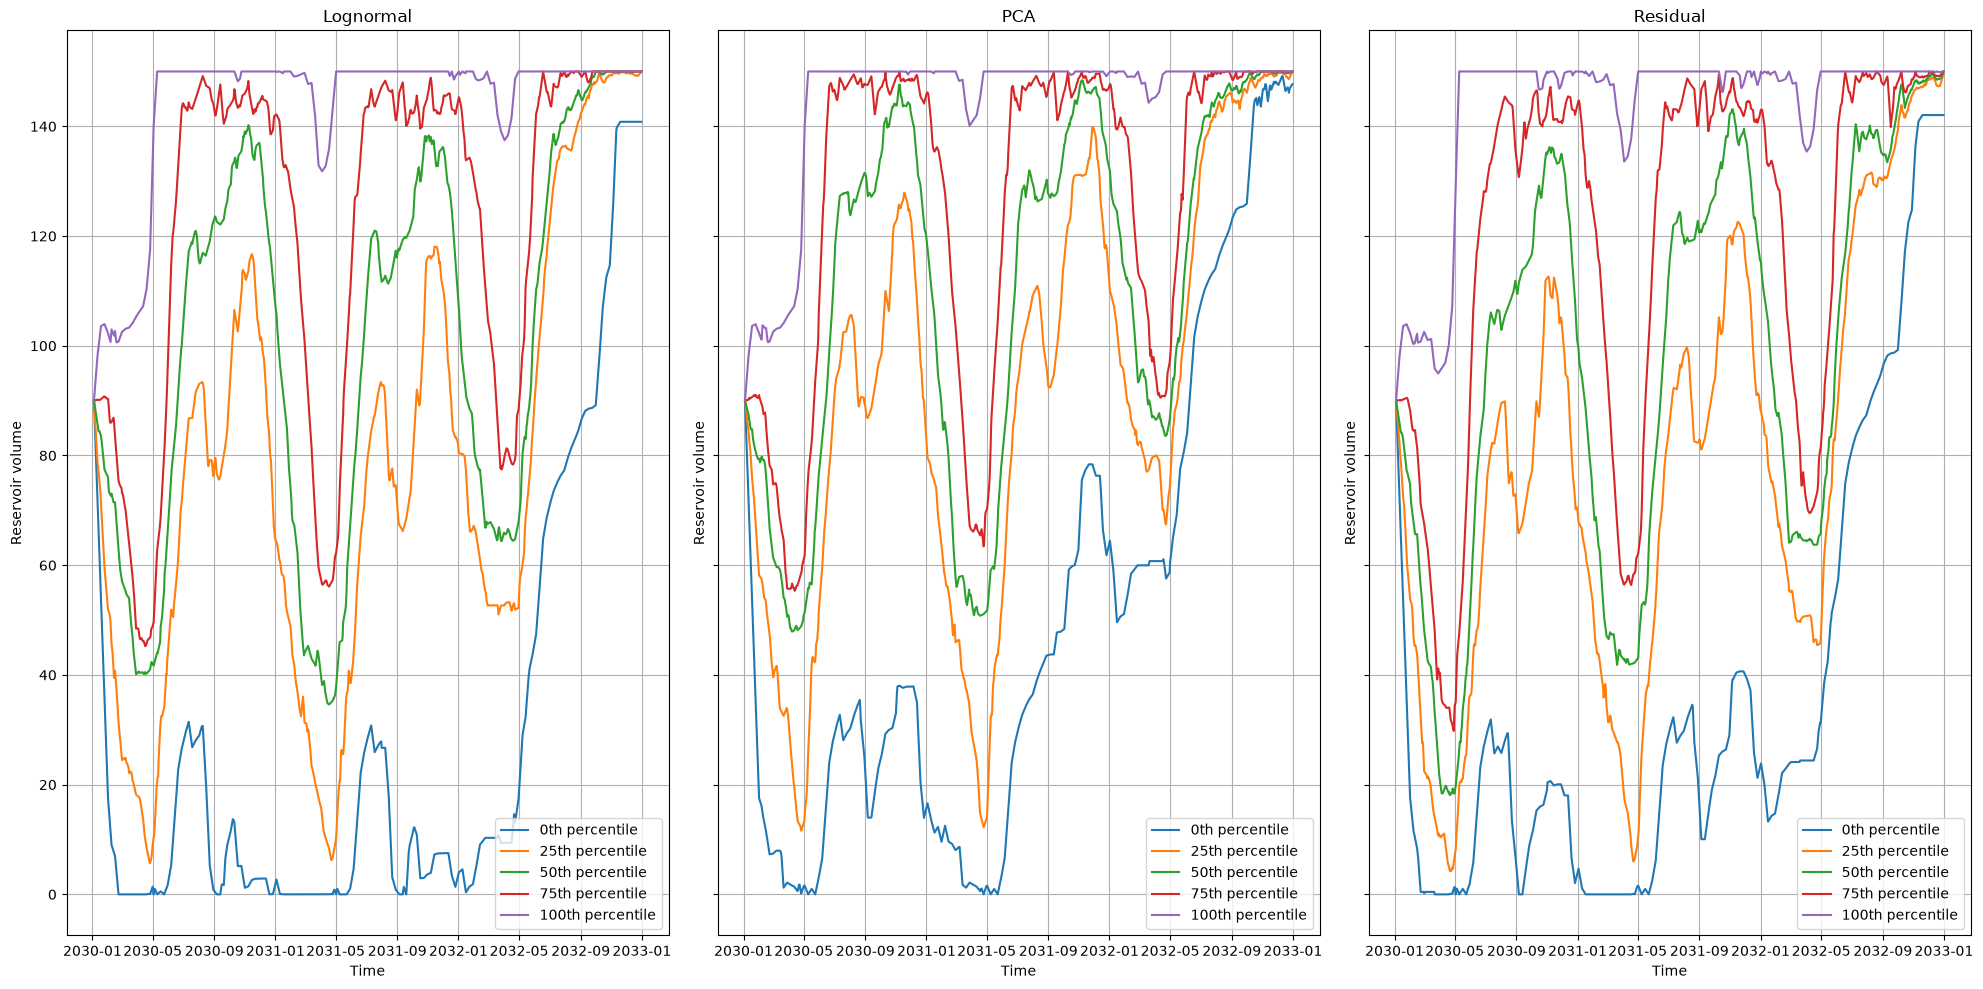

In [11]:
percs = [0, 25, 50, 75, 100]
log_perc_values = np.percentile(log_rsv_vols.values, percs, axis=1)
pca_perc_values = np.percentile(pca_rsv_vols.values, percs, axis=1)
res_perc_values = np.percentile(res_rsv_vols.values, percs, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(20, 10), sharey=True)

for p, values in zip(percs, log_perc_values):
    axes[0].plot(log_rsv_vols.index, values, label=f'{p}th percentile')
axes[0].set(title='Lognormal', xlabel='Time',ylabel="Reservoir volume")
axes[0].grid()
axes[0].legend()

for p, values in zip(percs, pca_perc_values):
    axes[1].plot(pca_rsv_vols.index, values, label=f'{p}th percentile')
axes[1].set(title='PCA', ylabel='Reservoir volume', xlabel='Time')
axes[1].grid()
axes[1].legend()

for p, values in zip(percs, res_perc_values):
    axes[2].plot(res_rsv_vols.index, values, label=f'{p}th percentile')
axes[2].set(title='Residual', ylabel='Reservoir volume', xlabel='Time')
axes[2].grid()
axes[2].legend()

fig.tight_layout()

In [12]:
print(f"Negative inflow for lognormal inflow-model: {log_neg_inflow}")
print(f"Negative inflow for PCA inflow-model: {pca_neg_inflow}")
print(f"Negative inflow for residual inflow-model: {res_neg_inflow}")

Negative inflow for lognormal inflow-model: None
Negative inflow for PCA inflow-model: None
Negative inflow for residual inflow-model: None


In [17]:
nscenarios = 30
nweeks = 156

log_vol = log_rsv_vols.to_numpy()
pca_vol = pca_rsv_vols.to_numpy()
res_vol = res_rsv_vols.to_numpy()

def income_generated(vol,prod,price,energy_conv):

    income = 0
    endVol = 0
    startVol = 0
    for i in range(nscenarios):
        for j in range(nweeks):
            income += prod[j, i] * price[j, i]       #unit is in 1000 EUR
        endVol += vol[-1, i]*price[:,i].mean() * energy_conv
        startVol += vol[0, i]*price[:,i].mean() * energy_conv
    adjusted_income = (income + endVol - startVol)/nscenarios
    income /= nscenarios
    return income, adjusted_income

log_income,log_adjusted_income = income_generated(log_vol,log_prod,log_price,energy_conv)
pca_income,pca_adjusted_income = income_generated(pca_vol,pca_prod,pca_price,energy_conv)
res_income,res_adjusted_income = income_generated(res_vol,res_prod,res_price,energy_conv)



print(f'Average income for lognormal: {log_income:.2f}')
print(f'Average income for PCA: {pca_income:.2f}')
print(f'Average income for residual: {res_income:.2f}')
print(f'Adjusted average income for lognormal: {log_adjusted_income:.2f}')
print(f'Adjusted average income for PCA: {pca_adjusted_income:.2f}')
print(f'Adjusted average income for residual: {res_adjusted_income:.2f}')

Average income for lognormal: 9187.71
Average income for PCA: 8731.39
Average income for residual: 9615.20
Adjusted average income for lognormal: 12348.00
Adjusted average income for PCA: 11911.53
Adjusted average income for residual: 12754.53
